<a href="https://colab.research.google.com/github/furalmiqbadi/PCVK26_01_AbdulGhofurAlmiqbadi/blob/main/P2_Tugas_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. PRAKTIKUM

## 1. Bikin koneksi antara Colab dengan Google Drive agar bisa mengakses file didalamnya.  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
from google.colab import files
uploaded = files.upload()

Saving KTM.jpg to KTM.jpg


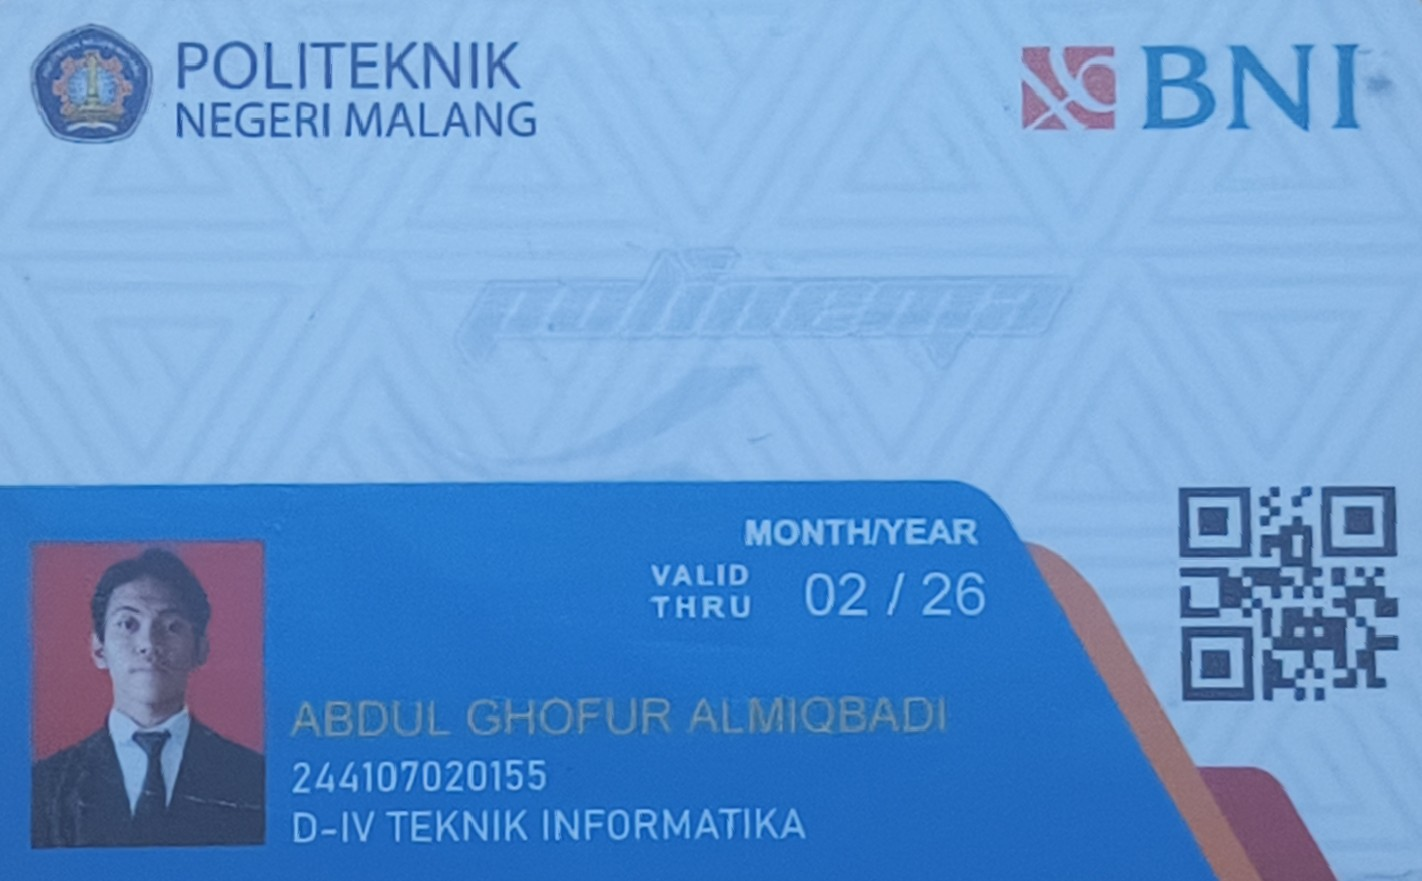

Resolusi gambar:  1422 x 881


In [27]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('/content/KTM.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

## 2. Menampilkan Gambar

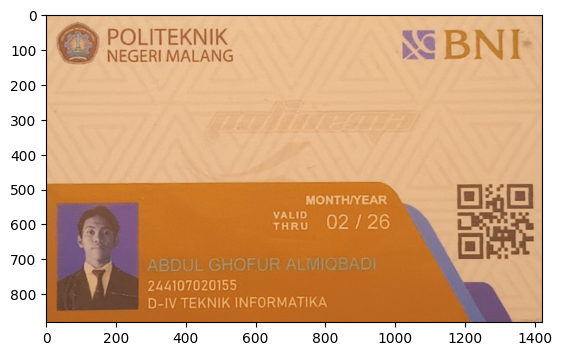

In [3]:
img = cv.imread('/content/KTM.jpg')
plt.imshow(img) #BGR

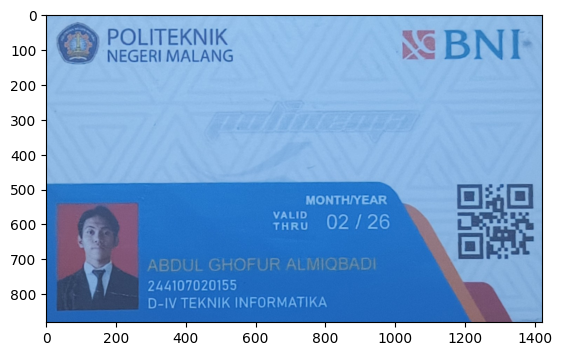

In [4]:
img = cv.imread('/content/KTM.jpg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) #BGR 2 RGB
plt.imshow(img2)

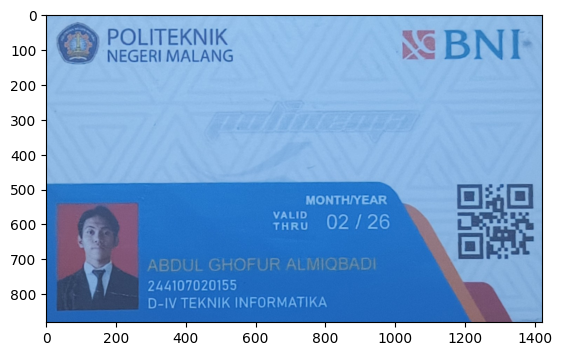

In [5]:
img = cv.imread('/content/KTM.jpg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) #BGR 2 RGB
plt.show()

## 3. Menampilkan citra Grayscale

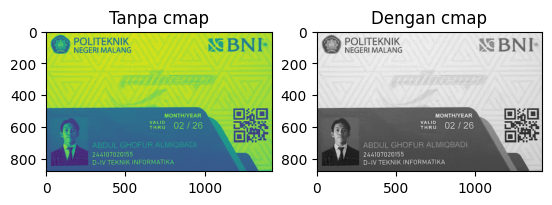

In [6]:
img_gray = cv.imread('/content/KTM.jpg', cv.IMREAD_GRAYSCALE)

#!cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

#cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")

plt.show()

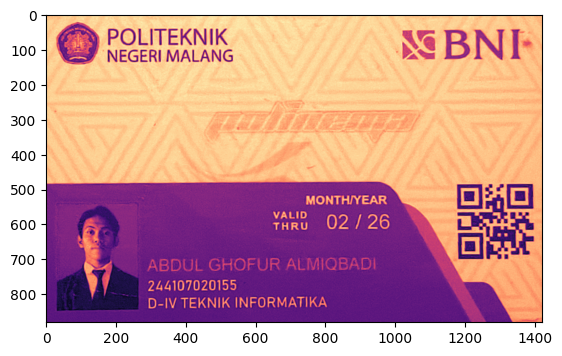

In [7]:
#cmap magma
plt.imshow(img_gray, cmap="magma")

## 4. Melakukan resizing

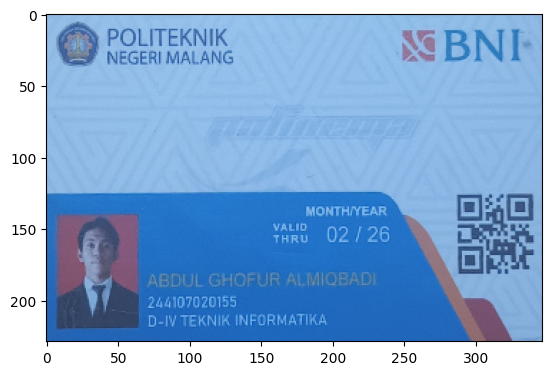

In [8]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB) #BGR 2 RGB
img_output = cv.resize(imgRGB, (347, 229))
plt.imshow(img_output)

## 5. Melakukan Flipping

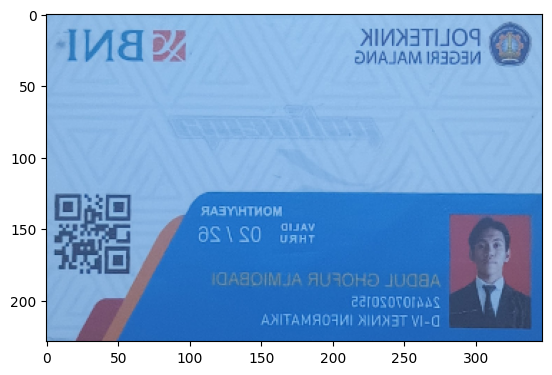

In [9]:
imgFlip = cv.flip(img_output, 1)
plt.imshow(imgFlip)

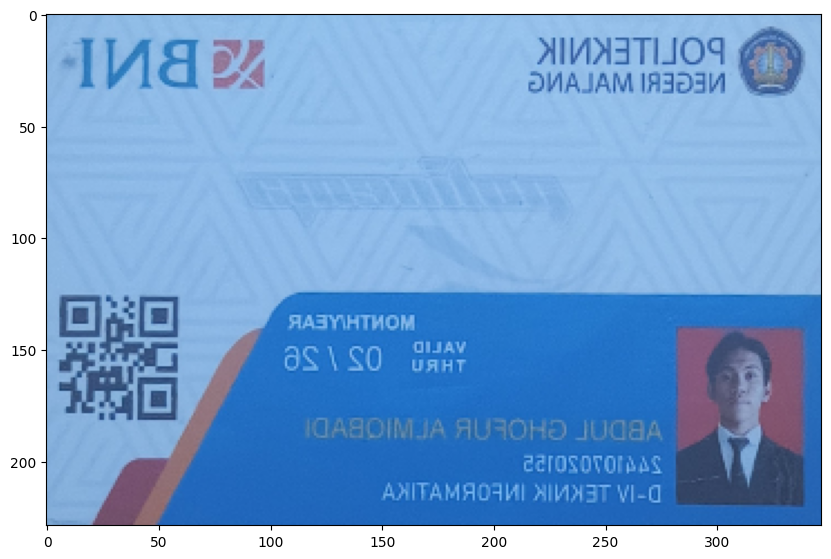

In [10]:
imgFlip = cv.flip(img_output, 1)

#Perbesar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

## 6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.

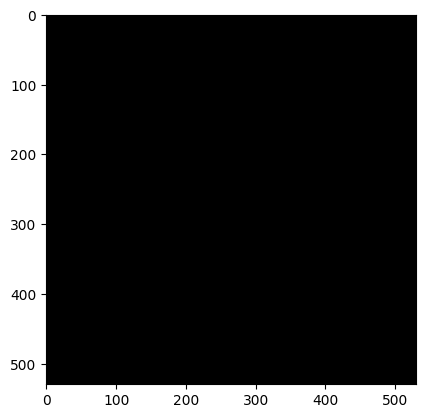

In [11]:
black_img = np.zeros(shape=(530,530,3), dtype=np.int16)
plt.imshow(black_img)

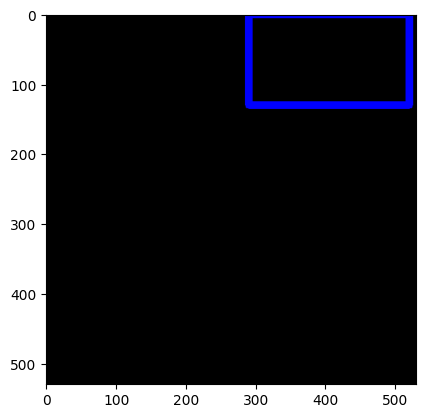

In [12]:
#Membuat kotak biru pada kordinat tertentu
cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0,0,255), thickness=10)
plt.imshow(black_img)

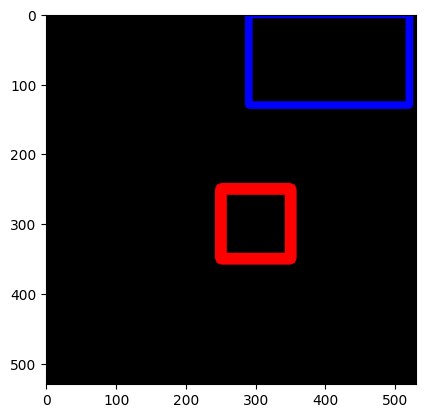

In [13]:
#Membuat kotak merah pada kordinat tertentu
cv.rectangle(black_img, pt1=(250,250), pt2=(350,350), color=(255,0,0), thickness=15)
plt.imshow(black_img)

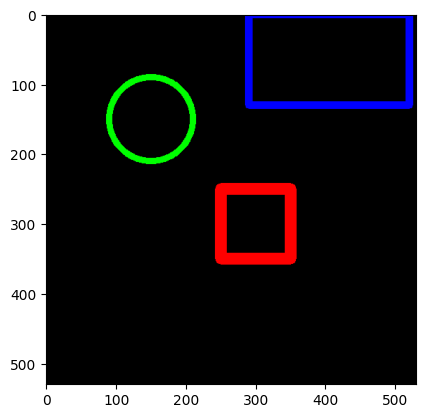

In [14]:
#Membuat lingkaran hijau pada kordinat tertentu
cv.circle(black_img, center=(150,150), radius=60, color=(0,255,0), thickness=8)
plt.imshow(black_img)

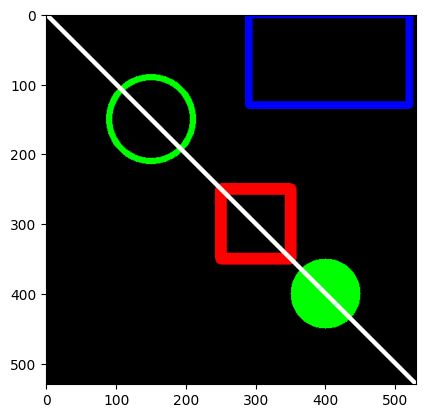

In [15]:
#Membuat lingkaran hijau full pada titik tertentu
cv.circle(black_img, center=(400,400), radius=50, color=(0,255,0), thickness=-1)
#Membuat garis putih pada kordinat tertentu
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255,255,255), thickness=5)
plt.imshow(black_img)

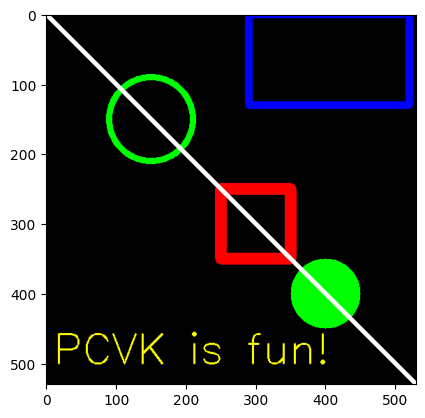

In [16]:
#Membuat teks kuning pada kordinat tertentu
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=2, lineType=cv.LINE_AA)
plt.imshow(black_img)

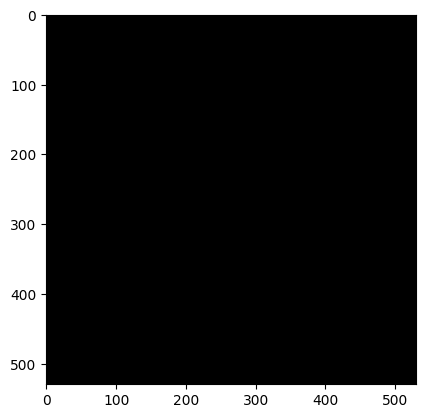

In [17]:
black_img2 = np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

In [18]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [19]:
pts = vertices.reshape((-1,1,2))
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

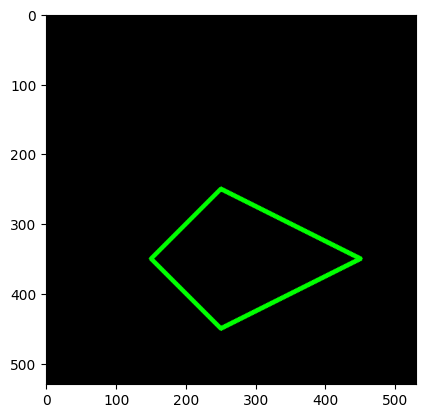

In [20]:
#Membuat layang layang hijau pada kordinat tertentu
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)



---


# PERTANYAAN PRAKTIKUM

SOAL:

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.
2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.
3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?
4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.
5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.

JAWAB:

1. Karena di cv2_imshow() menampilkan citra dalam format BGR, sedangkan plt.imshow() format RGB oleh karena itu warna merah dan biru dapat tertukar.

2. Kedua kanvas hitam terlihat sama saja bahkan min() dan max() juga sama bernilai 0. sedangkan untuk dtype yaitu int32 dan int 16 kemudian nbytes pada int32 dua kali lebih besar dari int16.

3. Jadi from google.colab.patches import cv2_imshow itu menyediakan fungsi alternatif untuk menampilkan gambar di Colab sementara cv2.imshow() itu bawaan OpenCV yang membutuhkan jendela GUI yang tidak tersedia di lingkungan Colab berbasis cloud tanpa antarmuka desktop sehingga tidak dapat digunakan langsung.

4. Citra dari skimage.io.imread() akan berada di format RGB sehingga menampilkan warna sebenarnya. Jadi jika dilakukan cv2.cvtColor(img, cv2.COLOR_BGR2RGB) pada citra yang dibaca dengan OpenCV dalam format BGR maka hasilnya warna merah dan biru tertukar.

5. Mengubah figsize hanya memperbesar ukuran tampilan plot dan tidak mengubah img.shape karena shape adalah properti array data citra. Jadi saat perubahan ukuran citra misal dengan cv2.resize() benar-benar mengubah jumlah piksel resolusi sehingga mengubah shape sedangkan figsize hanya mengatur skala tampilan di layar tanpa mengubah data asli.



---


# TUGAS PRAKTIKUM - Penerapan

## 1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.

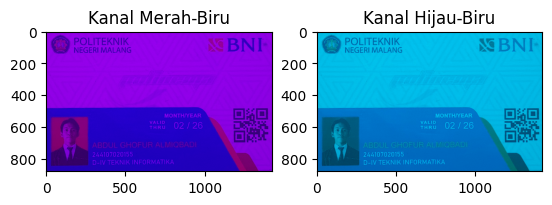

In [21]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#merah-biru
img_rb = imgRGB.copy()
img_rb[:, :, 1] = 0 #pada :(semua baris), :(semua kolom), 1(indeks RGB Hijau) ubah jadi 0

#hijau-biru
img_gb = imgRGB.copy()
img_gb[:, :, 0] = 0   #pada :(semua baris), :(semua kolom), 0(indeks RGB Mera) ubah jadi 0

#tampilan plot
plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title('Kanal Merah-Biru')

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title('Kanal Hijau-Biru')

plt.show()

## 2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

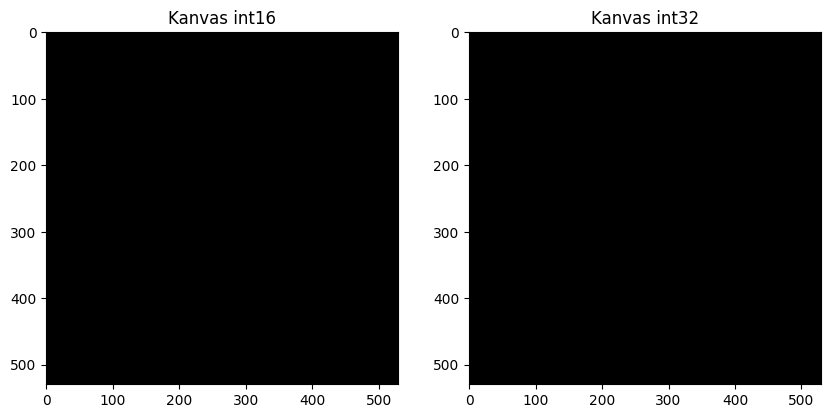

In [22]:
black_img16 = np.zeros(shape=(530,530,3), dtype=np.int16) #kanvas 16
black_img32 = np.zeros(shape=(530,530,3), dtype=np.int32) #kanvas 32
plt.figure(figsize=(10,5))

#tampilan plot
plt.subplot(1, 2, 1)
plt.imshow(black_img16)
plt.title('Kanvas int16')

plt.subplot(1, 2, 2)
plt.imshow(black_img32)
plt.title('Kanvas int32')

plt.show()

Perbandingan Atribut black_img16 dan black_img32

In [23]:
print("--- Atribut black_img16 ---")
print(f"dtype: {black_img16.dtype}")
print(f"min(): {black_img16.min()}")
print(f"max(): {black_img16.max()}")
print(f"nbytes: {black_img16.nbytes} bytes")

print("\n--- Atribut black_img32 ---")
print(f"dtype: {black_img32.dtype}")
print(f"min(): {black_img32.min()}")
print(f"max(): {black_img32.max()}")
print(f"nbytes: {black_img32.nbytes} bytes")

--- Atribut black_img16 ---
dtype: int16
min(): 0
max(): 0
nbytes: 1685400 bytes

--- Atribut black_img32 ---
dtype: int32
min(): 0
max(): 0
nbytes: 3370800 bytes


### Penjelasan:
Dari tampilan tidak ada perbedaan karena saat pembuatan ukuran dan warnanya sama persis

Untuk ukuran memori (nbytes) berbeda karena satunya int32 yang menggunakan 4 byte per elemen, sedangkan satunya int16 yang menggunakan 2 byte per elemen.

Untuk min() dan max() keduanya sama 0 karena tidak ada warna lain selain hitam alias min dan maxnya sama sama hitam atau 0

Untuk dtype berbeda karena ini untuk menunjukkan tipe data yang digunakan untuk menyimpan elemen array yang satunya int16 dan satunya int32

## 3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

In [39]:
from google.colab import files
uploaded = files.upload()

Saving Saya.jpeg to Saya (1).jpeg


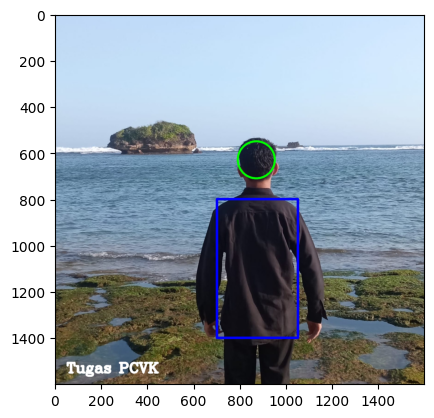

In [37]:
img_saya = cv.imread('/content/Saya.jpeg')
img_saya = cv.cvtColor(img_saya, cv.COLOR_BGR2RGB)

cv.circle(img_saya, center=(870,630), radius=80, color=(0,255,0), thickness=8)

cv.rectangle(img_saya, pt1=(700,800), pt2=(1050,1400), color=(0,0,255), thickness=10)

cv.putText(img_saya, text='Tugas PCVK',
               org=(50,1550),
               fontFace=cv.FONT_HERSHEY_COMPLEX,
               fontScale=2,
               color=(255, 255, 255),
               thickness=8,
               lineType=cv.LINE_AA)
plt.imshow(img_saya)



---

# TUGAS PRAKTIKUM - Analisa

Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

**Pertanyaan**

## 1. Apakah resize foto tanpa mengikuti rasio foto misal dari 16:9 jadi 4:3?



In [38]:
from google.colab import files
uploaded = files.upload()

Saving Lukisan.jpg to Lukisan.jpg


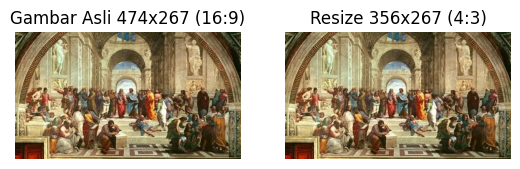

In [42]:
#img 16:9 contoh data 474x267
img_doksli = io.imread('/content/Lukisan.jpg')

#ubah ke ukuran 356x267 atau 4:3
img_diubah = cv.resize(img_doksli, (356, 267))

#tampilan plot
plt.subplot(1, 2, 1)
plt.imshow(img_doksli)
plt.title(f"Gambar Asli 474x267 (16:9)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_doksli)
plt.title(f"Resize 356x267 (4:3)")
plt.axis('off')

plt.show()

## 2. Bagaimana cara membuat gambar kosong atau kanvas berwarna selain hitam?

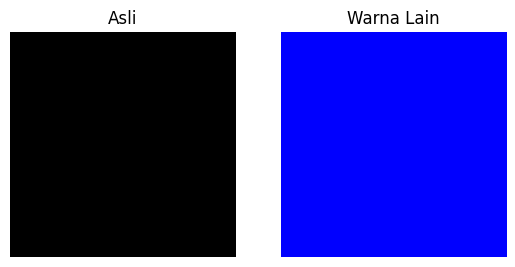

In [43]:
canvas_default = np.zeros((480, 480, 3), dtype=np.int32)

#diubah jadi biru
canvas_warna = canvas_default.copy()
canvas_warna[:, :, :] = [0, 0, 255]

#tampilan plot
plt.subplot(1, 2, 1)
plt.imshow(canvas_default)
plt.title(f"Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canvas_warna)
plt.title(f"Warna Lain")
plt.axis('off')
plt.show()




---
# TUGAS PRAKTIKUM - Aplikasi


## Studi Kasus 1

In [45]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import imageio as io
import matplotlib.pyplot as plt
import numpy as np

In [46]:
from google.colab import files
uploaded = files.upload()

Saving S1Potret.jpg to S1Potret.jpg
Saving S1Lanscape.jpg to S1Lanscape.jpg


In [56]:
def add_wm(img_path):
    img = io.imread(img_path)

    #ambil ukuran asli
    y_img, x_img = img.shape[0], img.shape[1]

    wm_img = img.copy()
    wm_height = int(y_img / 12) #ukuran kotak wm
    font_scale = wm_height / 70 #ukuran font

    #buat kotak hitam wm
    cv.rectangle(wm_img, (0, y_img-wm_height), (x_img, y_img), (0, 0, 0), thickness=-1)

    #teks wm
    cv.putText(wm_img, text='Dokumentasi PCVK - 2026',
               org=(int(x_img/40), y_img-int(wm_height/3)),
               fontFace=cv.FONT_HERSHEY_SIMPLEX,
               fontScale=font_scale,
               color=(255, 255, 255),
               thickness=3,
               lineType=cv.LINE_AA)

    #return
    return wm_img

/tmp/ipykernel_1001/3796409175.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img1_nowm = io.imread('/content/S1Lanscape.jpg')
/tmp/ipykernel_1001/3796409175.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img2_nowm = io.imread('/content/S1Potret.jpg')


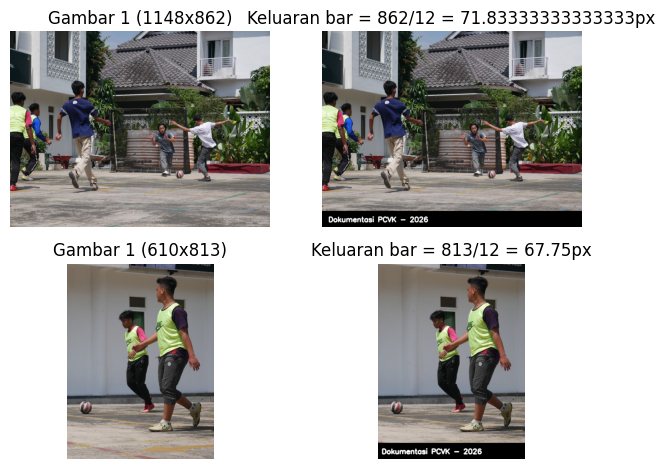

In [57]:
#path + fungsi
img1_nowm = io.imread('/content/S1Lanscape.jpg')
img2_nowm = io.imread('/content/S1Potret.jpg')
img1_wmed = add_wm('/content/S1Lanscape.jpg')
img2_wmed = add_wm('/content/S1Potret.jpg')

#tampilan plot
plt.subplot(2, 2, 1)
plt.imshow(img1_nowm)
plt.title(f"Gambar 1 ({img1_nowm.shape[1]}x{img1_nowm.shape[0]})")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img1_wmed)
plt.title(f"Keluaran bar = {img1_wmed.shape[0]}/12 = {img1_wmed.shape[0]/12}px")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img2_nowm)
plt.title(f"Gambar 1 ({img2_nowm.shape[1]}x{img2_nowm.shape[0]})")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img2_wmed)
plt.title(f"Keluaran bar = {img2_wmed.shape[0]}/12 = {img2_wmed.shape[0]/12}px")
plt.axis('off')

plt.tight_layout()
plt.show()

## Studi Kasus 2

In [58]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import imageio as io
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

In [59]:
def as_profile(img_path):
    img = io.imread(img_path)
    y_img, x_img = img.shape[0], img.shape[1]  #y/tinggi, x/lebar

    #cari terpanjang
    length_profile = max(y_img, x_img)

    #cari offset buat nyari tengahnya
    y_offset = (length_profile-y_img)//2
    x_offset = (length_profile-x_img)//2

    #buat kanvas putih
    white_img = np.zeros((length_profile, length_profile, 3), dtype=np.int32)
    white_img[:, :, :] = [255, 255, 255]

    #tempel gambar ditengah
    white_img[y_offset:y_offset + y_img, x_offset:x_offset + x_img] = img

    #return
    return white_img

/tmp/ipykernel_1001/3947925779.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = io.imread(img_path)


Text(0.5, 1.0, '1148x1148')

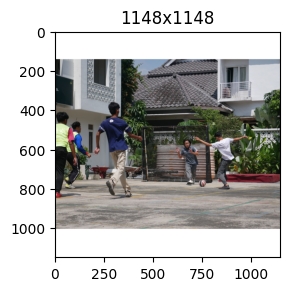

In [60]:
#path + fungsi
img_profile = as_profile('/content/S1Lanscape.jpg')

#tampilan plot
plt.subplot(1, 2, 1)
plt.imshow(img_profile)
plt.title(f"{img_profile.shape[0]}x{img_profile.shape[0]}")